<a href="https://colab.research.google.com/github/enoklestari/fuzzy_PV_package/blob/main/Tugas3_Retno_Dwi_Lestari_6022251018.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fuzzy Area Input [Sedikit, Sedang, Banyak]:
[0.23333333 0.65       0.        ]
Fuzzy Daya Input [Kecil, Menengah, Besar]:
[0.  0.8 0. ]
Crisp Output (Harga Paket): Rp 313.02 Miliar


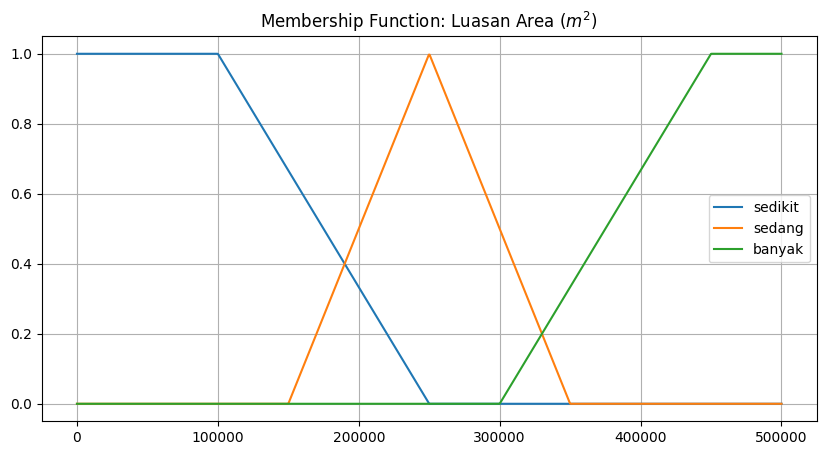

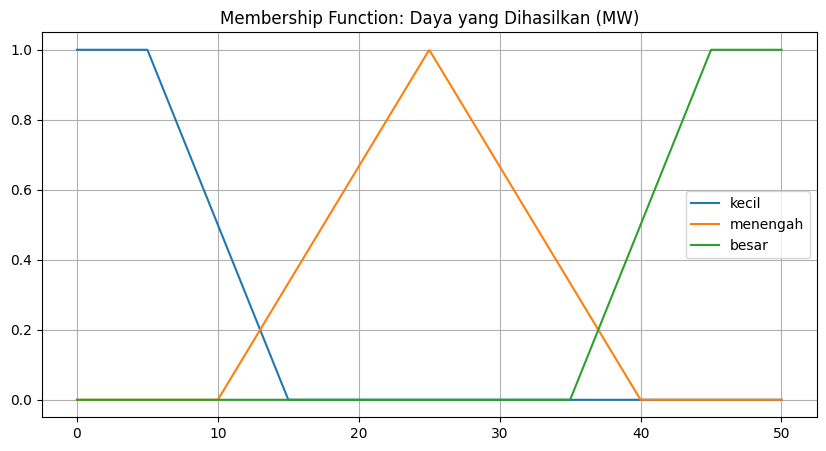

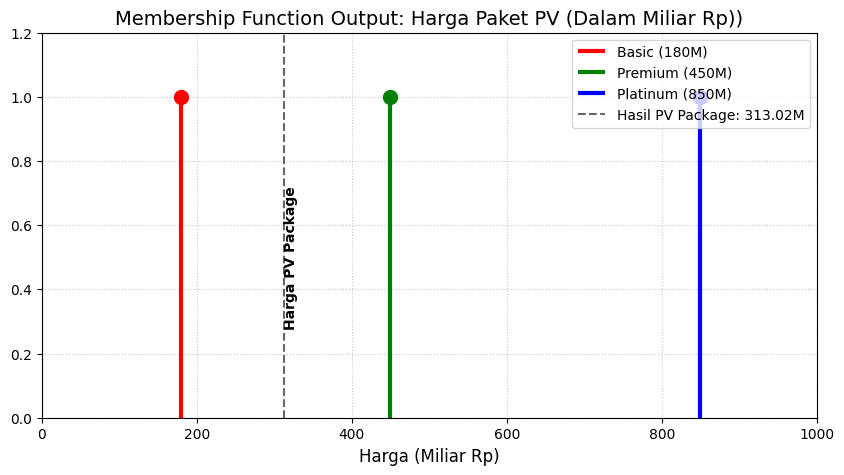

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def triangle(x, a, b, c, d, e):
    if x < a:
        return d
    elif a <= x <= b:
        if a == b:
          return d
        return (x - a) / (b - a)
    elif b < x <= c:
        if b == c:
          return e
        return (c - x) / (c - b)
    elif x > c:
        return e
    else:
        return 0


def fuzifikasi_area(area):
    sedikit = triangle(area, 100000, 100000, 250000, 1, 0)
    sedang  = triangle(area, 150000, 250000, 350000, 0, 0)
    banyak  = triangle(area, 300000, 450000, 450000, 0, 1)
    return np.array([sedikit, sedang, banyak])


def fuzifikasi_daya(daya):
    kecil    = triangle(daya, 5, 5, 15, 1, 0)
    menengah = triangle(daya, 10, 25, 40, 0, 0)
    besar    = triangle(daya, 35, 45, 45, 0, 1)
    return np.array([kecil, menengah, besar])


in_fuzzy_area = 215000
in_fuzzy_daya = 28

fuzzy_area = fuzifikasi_area(in_fuzzy_area)
fuzzy_daya = fuzifikasi_daya(in_fuzzy_daya)

# Singleton Output (Harga dalam Miliar Rp)
rule_FD = np.array([
    [140, 210, 280],
    [160, 350, 600],
    [200, 450, 800]
])

num = 0
denum = 0
for i, val_area in enumerate(fuzzy_area):
    for j, val_daya in enumerate(fuzzy_daya):
        min_val = min(val_area, val_daya)
        num = num + min_val * rule_FD[i][j]
        denum = denum + min_val

crisp_output = num/denum

print("Fuzzy Area Input [Sedikit, Sedang, Banyak]:")
print(fuzzy_area)
print("Fuzzy Daya Input [Kecil, Menengah, Besar]:")
print(fuzzy_daya)
print(f"Crisp Output (Harga Paket): Rp {crisp_output:.2f} Miliar")

#Plot Input Area
semua_area = np.linspace(0, 500000, 1000)
hasil_area = np.zeros((len(semua_area), 3))
for i, val in enumerate(semua_area):
    hasil_area[i] = fuzifikasi_area(val)

plt.figure(figsize=(10, 5))
plt.plot(semua_area, hasil_area[:,0], label="sedikit")
plt.plot(semua_area, hasil_area[:,1], label="sedang")
plt.plot(semua_area, hasil_area[:,2], label="banyak")
plt.title("Membership Function: Luasan Area ($m^2$)")
plt.legend()
plt.grid(True)
plt.show()

#Plot Input Daya
semua_daya = np.linspace(0, 50, 1000)
hasil_daya = np.zeros((len(semua_daya), 3))
for i, val in enumerate(semua_daya):
    hasil_daya[i] = fuzifikasi_daya(val)

plt.figure(figsize=(10, 5))
plt.plot(semua_daya, hasil_daya[:,0], label="kecil")
plt.plot(semua_daya, hasil_daya[:,1], label="menengah")
plt.plot(semua_daya, hasil_daya[:,2], label="besar")
plt.title("Membership Function: Daya yang Dihasilkan (MW)")
plt.legend()
plt.grid(True)
plt.show()

#Plot Output Harga PV
output_harga = [180, 450, 850]
labels = ["Basic (180M)", "Premium (450M)", "Platinum (850M)"]
colors = ['red', 'green', 'blue']

plt.figure(figsize=(10, 5))
for i in range(len(output_simple)):
    plt.vlines(output_simple[i], 0, 1, colors=colors[i], linestyles='solid', linewidth=3, label=labels[i])
    plt.scatter(output_simple[i], 1, color=colors[i], s=100, zorder=3)

plt.axvline(x=crisp_output, color='black', linestyle='--', alpha=0.6, label=f'Hasil PV Package: {crisp_output:.2f}M')
plt.text(crisp_output, 0.5, 'Harga PV Package', rotation=90, verticalalignment='center', fontweight='bold')

plt.title("Membership Function Output: Harga Paket PV (Dalam Miliar Rp))", fontsize=14)
plt.xlabel("Harga (Miliar Rp)", fontsize=12)
plt.xlim(0, 1000)
plt.ylim(0, 1.2)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()


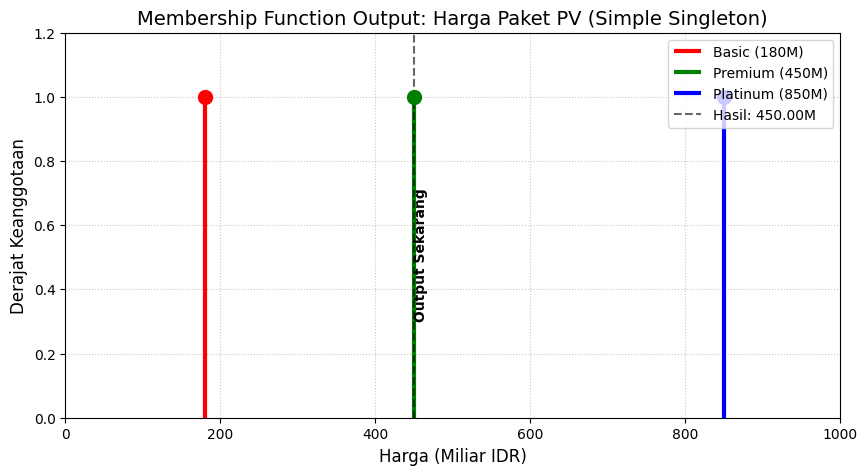

In [21]:
output_simple = [180, 450, 850]
labels = ["Basic (180M)", "Premium (450M)", "Platinum (850M)"]
colors = ['red', 'green', 'blue']

plt.figure(figsize=(10, 5))

# Plot 3 garis tegak (Singleton)
for i in range(len(output_simple)):
    plt.vlines(output_simple[i], 0, 1, colors=colors[i], linestyles='solid', linewidth=3, label=labels[i])
    plt.scatter(output_simple[i], 1, color=colors[i], s=100, zorder=3)

# Tambahan: Tampilkan di mana posisi Crisp Output hasil perhitungan saat ini
plt.axvline(x=crisp_output, color='black', linestyle='--', alpha=0.6, label=f'Hasil: {crisp_output:.2f}M')
plt.text(crisp_output, 0.5, ' Output Sekarang', rotation=90, verticalalignment='center', fontweight='bold')

plt.title("Membership Function Output: Harga Paket PV (Dalam Miliar Rp))", fontsize=14)
plt.xlabel("Harga (Miliar IDR)", fontsize=12)
plt.ylabel("Derajat Keanggotaan", fontsize=12)
plt.xlim(0, 1000)
plt.ylim(0, 1.2)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

In [ ]:
harga_basic = [140, 160, 180]
harga_premium = [380, 410, 440, 450]
harga_platinum = [750, 850]

plt.figure(figsize=(10, 6))
plt.vlines(harga_basic, 0, 1, colors='red', linestyles='solid', linewidth=2, label="Basic")
plt.vlines(harga_premium, 0, 1, colors='green', linestyles='solid', linewidth=2, label="Premium")
plt.vlines(harga_platinum, 0, 1, colors='blue', linestyles='solid', linewidth=2, label="Platinum")
plt.scatter(harga_basic + harga_premium + harga_platinum, [1]*9, color='black', s=30, zorder=3)
plt.title("Membership Function Output: Harga Paket PV (Miliar Rp)")
plt.xlabel("Harga (Miliar IDR)")
plt.xlim(0, 1000)
plt.ylim(0, 1.2)
plt.legend()
plt.grid()
plt.show()
